# Variante 3: Multiprocessing Dynamic

Worker holen sich dynamisch neue Bilder aus einer internen Queue, sobald sie frei sind.

Hypothese: Dynamic ist bei variabler Auflösung (Kaggle Pneumonia) im Vorteil, weil kein Prozess idle wartet während ein anderer noch ein großes Bild verarbeitet. Bei gleicher Auflösung (NIH) bringt Dynamic keinen Vorteil.

Technologie: multiprocessing.Pool mit imap_unordered (chunksize=1)

#### Imports

In [6]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import statistics
from pathlib import Path
from functools import partial

from pipeline import process_image, get_image_paths

print(f"CPU-Kerne verfügbar: {multiprocessing.cpu_count()}")

CPU-Kerne verfügbar: 8


#### Konfiguration
Hinweis: Bitte an eigenes lokales Set-Up anpassen
(Laptop 1 = Maxim, Laptop 2 = Ella, Laptop 3 = Jordan)

In [7]:
LAPTOP_ID = 1

IMG_SIZE = (512, 512)
RUNS = 10

NIH_DIR    = "../data/nih_chest_xray"
KAGGLE_DIR = "../data/kaggle_pneumonia"

RESULTS_DIR = f"results/laptop{LAPTOP_ID}"
RESULTS_CSV = f"{RESULTS_DIR}/results_dynamic_laptop{LAPTOP_ID}.csv"

IMAGE_COUNTS   = [100, 500, 1000, 5000]
PROCESS_COUNTS = [1, 2, 4, 8]
CHUNKSIZE      = 1

Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

#### 1. Get Images

In [8]:
nih_paths    = get_image_paths(NIH_DIR)
kaggle_paths = get_image_paths(KAGGLE_DIR)

print(f"NIH Bilder gefunden:              {len(nih_paths)}")
print(f"Kaggle Pneumonia Bilder gefunden: {len(kaggle_paths)}")

NIH Bilder gefunden:              5000
Kaggle Pneumonia Bilder gefunden: 5000


#### 2. Process Image

In [9]:
def run_dynamic(image_paths, n_processes, chunksize=1):
    t_start = time.perf_counter()
    with multiprocessing.Pool(processes=n_processes) as pool:
        results = list(pool.imap_unordered(process_image, image_paths, chunksize=chunksize))
    total_time = time.perf_counter() - t_start
    return total_time, results

#### 3. Run

In [10]:
def benchmark():
    rows = []

    datasets = [
        ("NIH",              nih_paths),
        ("Kaggle Pneumonia", kaggle_paths),
    ]

    for dataset_name, all_paths in datasets:
        print(f"\n=== {dataset_name} ===")

        for n_img in IMAGE_COUNTS:
            subset = all_paths[:n_img]
            if len(subset) < n_img:
                print(f"  Nur {len(subset)} Bilder verfügbar (angefragt: {n_img})")
                continue

            for n_proc in PROCESS_COUNTS:
                runtimes = []
                for run in range(RUNS):
                    runtime, _ = run_dynamic(subset, n_proc, chunksize=CHUNKSIZE)
                    runtimes.append(runtime)

                median_runtime    = statistics.median(runtimes)
                median_throughput = n_img / median_runtime

                rows.append({
                    "Laptop":        LAPTOP_ID,
                    "Variante":      "Dynamic",
                    "Datensatz":     dataset_name,
                    "Bilder":        n_img,
                    "Prozesse":      n_proc,
                    "Laufzeit in s": round(median_runtime, 3),
                    "Speedup":       None,
                    "Efficiency":    None,
                    "Throughput":    round(median_throughput, 2),
                })
                print(f"  {n_img} Bilder | {n_proc} Prozesse | Median: {median_runtime:.3f}s")

    return pd.DataFrame(rows)

df = benchmark()
df


=== NIH ===
  100 Bilder | 1 Prozesse | Median: 0.821s
  100 Bilder | 2 Prozesse | Median: 0.503s
  100 Bilder | 4 Prozesse | Median: 0.400s
  100 Bilder | 8 Prozesse | Median: 0.479s
  500 Bilder | 1 Prozesse | Median: 3.953s
  500 Bilder | 2 Prozesse | Median: 2.081s
  500 Bilder | 4 Prozesse | Median: 1.502s
  500 Bilder | 8 Prozesse | Median: 1.306s
  1000 Bilder | 1 Prozesse | Median: 8.031s
  1000 Bilder | 2 Prozesse | Median: 4.244s
  1000 Bilder | 4 Prozesse | Median: 2.794s
  1000 Bilder | 8 Prozesse | Median: 2.219s
  5000 Bilder | 1 Prozesse | Median: 36.329s
  5000 Bilder | 2 Prozesse | Median: 20.762s
  5000 Bilder | 4 Prozesse | Median: 12.757s
  5000 Bilder | 8 Prozesse | Median: 8.629s

=== Kaggle Pneumonia ===
  100 Bilder | 1 Prozesse | Median: 1.277s
  100 Bilder | 2 Prozesse | Median: 0.804s
  100 Bilder | 4 Prozesse | Median: 0.583s
  100 Bilder | 8 Prozesse | Median: 0.648s
  500 Bilder | 1 Prozesse | Median: 5.780s
  500 Bilder | 2 Prozesse | Median: 3.230s
  50

,Laptop,Variante,Datensatz,Bilder,Prozesse,Laufzeit in s,Speedup,Efficiency,Throughput
0,1,Dynamic,NIH,100,1,0.821,None,None,121.85
1,1,Dynamic,NIH,100,2,0.503,None,None,198.68
2,1,Dynamic,NIH,100,4,0.400,None,None,249.79
3,1,Dynamic,NIH,100,8,0.479,None,None,208.69
4,1,Dynamic,NIH,500,1,3.953,None,None,126.50
5,1,Dynamic,NIH,500,2,2.081,None,None,240.33
6,1,Dynamic,NIH,500,4,1.502,None,None,332.85
7,1,Dynamic,NIH,500,8,1.306,None,None,382.91
8,1,Dynamic,NIH,1000,1,8.031,None,None,124.52
9,1,Dynamic,NIH,1000,2,4.244,None,None,235.60


#### 4. Speedup und Efficiency

In [11]:
baseline = (
    df[df["Prozesse"] == 1]
    .set_index(["Datensatz", "Bilder"])["Laufzeit in s"]
)

df["Speedup"]    = df.apply(lambda r: round(baseline.get((r["Datensatz"], r["Bilder"]), float("nan")) / r["Laufzeit in s"], 3), axis=1)
df["Efficiency"] = df.apply(lambda r: round(r["Speedup"] / r["Prozesse"], 3), axis=1)

df.to_csv(RESULTS_CSV, index=False)
print(f"Gespeichert: {RESULTS_CSV}")
df

Gespeichert: results/laptop1/results_dynamic_laptop1.csv


,Laptop,Variante,Datensatz,Bilder,Prozesse,Laufzeit in s,Speedup,Efficiency,Throughput
0,1,Dynamic,NIH,100,1,0.821,1.000,1.000,121.85
1,1,Dynamic,NIH,100,2,0.503,1.632,0.816,198.68
2,1,Dynamic,NIH,100,4,0.400,2.052,0.513,249.79
3,1,Dynamic,NIH,100,8,0.479,1.714,0.214,208.69
4,1,Dynamic,NIH,500,1,3.953,1.000,1.000,126.50
5,1,Dynamic,NIH,500,2,2.081,1.900,0.950,240.33
6,1,Dynamic,NIH,500,4,1.502,2.632,0.658,332.85
7,1,Dynamic,NIH,500,8,1.306,3.027,0.378,382.91
8,1,Dynamic,NIH,1000,1,8.031,1.000,1.000,124.52
9,1,Dynamic,NIH,1000,2,4.244,1.892,0.946,235.60


#### 5. Plots

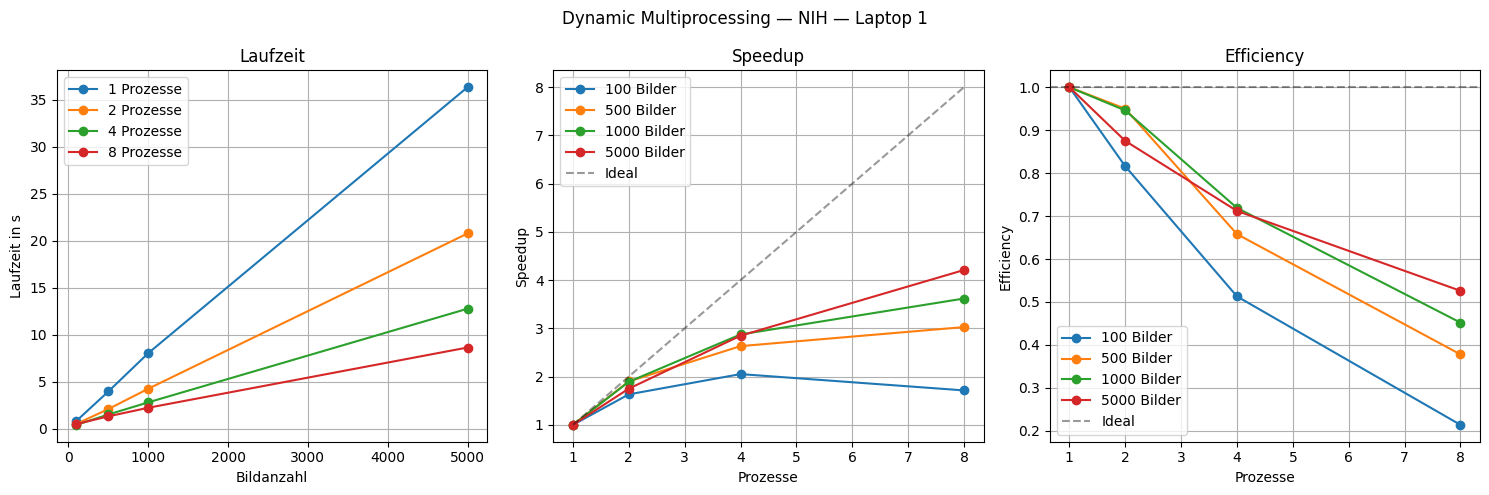

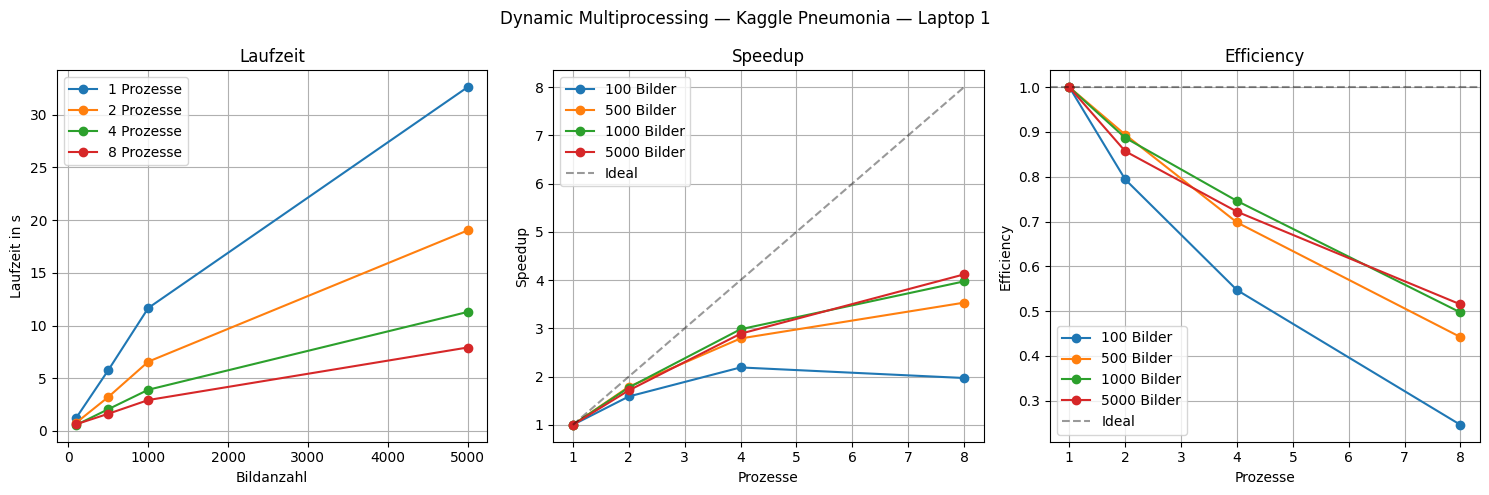

In [12]:
Path("plots").mkdir(exist_ok=True)

for dataset_name in ["NIH", "Kaggle Pneumonia"]:
    sub_ds = df[df["Datensatz"] == dataset_name]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Dynamic Multiprocessing — {dataset_name} — Laptop {LAPTOP_ID}")

    ax = axes[0]
    for n_proc in PROCESS_COUNTS:
        sub = sub_ds[sub_ds["Prozesse"] == n_proc]
        ax.plot(sub["Bilder"], sub["Laufzeit in s"], marker="o", label=f"{n_proc} Prozesse")
    ax.set_xlabel("Bildanzahl")
    ax.set_ylabel("Laufzeit in s")
    ax.set_title("Laufzeit")
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    for n_img in IMAGE_COUNTS:
        sub = sub_ds[sub_ds["Bilder"] == n_img]
        if not sub.empty:
            ax.plot(sub["Prozesse"], sub["Speedup"], marker="o", label=f"{n_img} Bilder")
    ax.plot(PROCESS_COUNTS, PROCESS_COUNTS, "k--", alpha=0.4, label="Ideal")
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Speedup")
    ax.set_title("Speedup")
    ax.legend()
    ax.grid(True)

    ax = axes[2]
    for n_img in IMAGE_COUNTS:
        sub = sub_ds[sub_ds["Bilder"] == n_img]
        if not sub.empty:
            ax.plot(sub["Prozesse"], sub["Efficiency"], marker="o", label=f"{n_img} Bilder")
    ax.axhline(1.0, color="k", linestyle="--", alpha=0.4, label="Ideal")
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Efficiency")
    ax.set_title("Efficiency")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    fname = f"{RESULTS_DIR}/dynamic_{dataset_name.lower().replace(' ', '_')}_laptop{LAPTOP_ID}.png"
    plt.savefig(fname, dpi=150)
    plt.show()

#### 6. Idle-Time Analyse
Veranschaulichung der Variation der Laufzeit zwischen den einzelnen Bildern

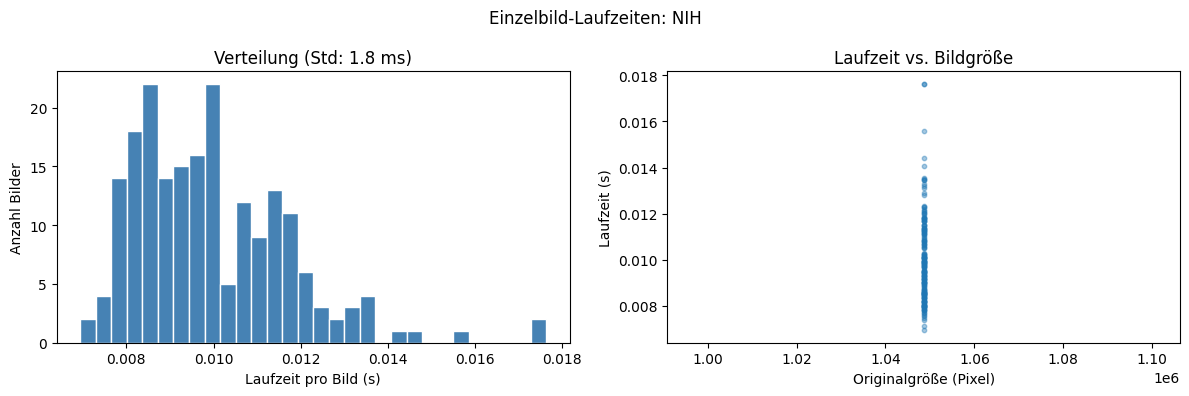

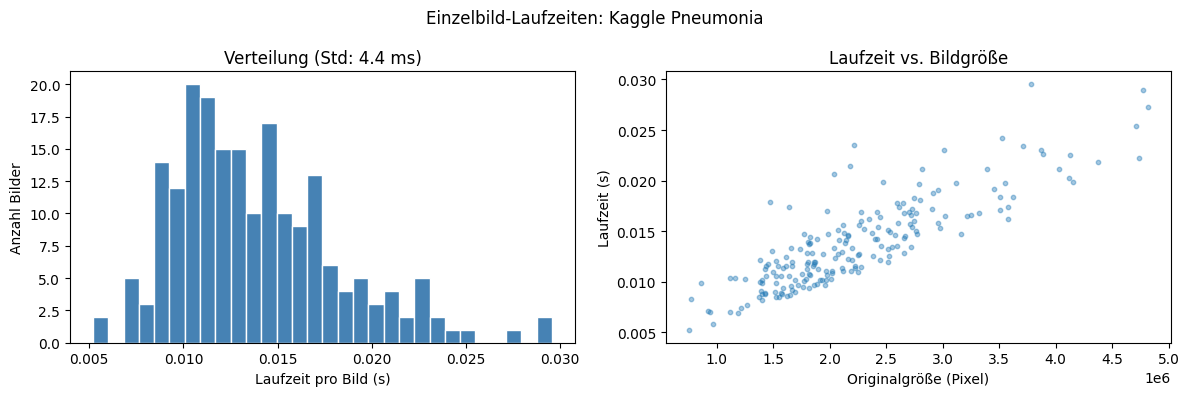

: 

In [ ]:
for ds_label, paths in [("NIH", nih_paths[:200]), ("Kaggle Pneumonia", kaggle_paths[:200])]:
    if len(paths) == 0:
        continue

    _, results = run_dynamic(paths, n_processes=4)
    durations  = [r["duration_s"]    for r in results if r["success"]]
    sizes      = [r["original_size"] for r in results if r["success"] and r["original_size"]]
    pixels     = [w * h for w, h in sizes]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Einzelbild-Laufzeiten: {ds_label}")

    axes[0].hist(durations, bins=30, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Laufzeit pro Bild (s)")
    axes[0].set_ylabel("Anzahl Bilder")
    axes[0].set_title(f"Verteilung (Std: {np.std(durations)*1000:.1f} ms)")

    if pixels:
        axes[1].scatter(pixels, durations, alpha=0.4, s=10)
        axes[1].set_xlabel("Originalgröße (Pixel)")
        axes[1].set_ylabel("Laufzeit (s)")
        axes[1].set_title("Laufzeit vs. Bildgröße")

    plt.tight_layout()
    fname = f"{RESULTS_DIR}/idle_{ds_label.lower().replace(' ', '_')}_laptop{LAPTOP_ID}.png"
    plt.savefig(fname, dpi=150)
    plt.show()